# Dictionary-based Sentiment Analysis on Airline Tweets

In [1]:
import numpy as np
import pandas as pd
import random
np.random.seed(42)  # Set seed for NumPy
random.seed(42) # Set seed for random module
import nltk
import string

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Data

The dataset contains tweets about different Airlines.

Run the code below.

In [3]:
tweets = pd.read_csv("https://raw.githubusercontent.com/kbrennig/MODS_WS25_26/refs/heads/main/data/airlinetweets.csv")

In [4]:
tweets.head()

,tweet_id,airline,text,sentiment_human,tweet_created
0,5.698464e+17,American,@AmericanAir thank you for doing the best you ...,positive,2015-02-23
1,5.697151e+17,American,@AmericanAir wow that's helpful.,positive,2015-02-22
2,5.678138e+17,United,@united so I wasted 40mins filling in 2 online...,negative,2015-02-17
3,5.702325e+17,American,@AmericanAir my seat is disgusting. Old and di...,negative,2015-02-24
4,5.696695e+17,US Airways,@USAirways ur specialist said they would talk ...,negative,2015-02-22


## Preprocessing
Since unstructured data doesn't have an inherent and consistent structure we have to perform some preprocessing steps in order to make the data usable for the computer.
One thing to keep in mind is that the more preprocessing we perform the more information we lose, but the basic methods we are using here require it.

### Tokenize documents
First, we tokenize the texts. This means we transform the texts from one long string to a list of tokens. Additionally we also start removing unwanted characters (e.g punctuation between sentences, numbers, etc.).
For a full list and explanation of the used parameters you can have a look at the documentation.

### Stem all words
After tokenizing the texts we perform stemming (alternatively lemmatization could be performed). Stemming reduces every word to its stem.
The stemmer we use here is the Porter Stemmer.

### Remove stopwords
Finally we remove words that don't contain real meaning and are commonly used (e.g. 'this', 'the', 'a', etc.).

Run the code below.



In [5]:
# Download the necessary nltk resource
nltk.download('punkt_tab')
nltk.download('stopwords')

def preprocess(text):
    # tokenize the text
    tokens = nltk.word_tokenize(text)

    # create stemmer object
    stemmer = nltk.stem.PorterStemmer()

    # stem each token
    stemmed_tokens = [stemmer.stem(token) for token in tokens]

    # get list of stopwords in English
    stopwords = nltk.corpus.stopwords.words("english")

    # remove stopwords
    filtered_tokens = [token for token in stemmed_tokens if token.lower() not in stopwords]
    
    # remove punctuation
    filtered_tokens_nopunct = [token for token in filtered_tokens if token not in string.punctuation]

    return filtered_tokens_nopunct

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/oliver/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/oliver/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Apply the preprocessing function

In [6]:
tweets['tokens'] = tweets['text'].apply(preprocess)
tweets.iloc[0]

tweet_id                                        569846356409339904.0
airline                                                     American
text               @AmericanAir thank you for doing the best you ...
sentiment_human                                             positive
tweet_created                                             2015-02-23
tokens             [americanair, thank, best, could, get, rebook,...
Name: 0, dtype: object

## Dictionary-Based Sentiment Analysis
`Dictionary-based Sentiment Analysis` works by looking up the sentiment of each word occurring in a text in a `sentiment dictionary`. Afterwards the single sentiment scores are summed up to evaluate the text's sentiment.

### Load NRC sentiment dictionary
We use the NRC sentiment dictionary. This dictionary contains ten classes: anger, anticipation, disgust, fear, joy, negative, positive, sadness, surprise and trust.
Currently we are only interested in positive and negative words.

Run the code below.

In [7]:
# Load NRC Emotion Lexicon
nrc_df = pd.read_csv('https://raw.githubusercontent.com/kbrennig/MODS_WS25_26/refs/heads/main/data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', sep='\t', header=None, names=['word', 'emotion', 'association'])

# Filter out rows where association is 0
nrc_df = nrc_df[nrc_df['association'] == 1]

# Define positive and negative emotion categories
positive_emotions = {'positive'}
negative_emotions = {'negative'}

# Filter words by emotion category and collect unique words for each sentiment orientation
positive_words = nrc_df[nrc_df['emotion'].isin(positive_emotions)]['word'].unique()
negative_words = nrc_df[nrc_df['emotion'].isin(negative_emotions)]['word'].unique()



We can look at an excerpt of the positive words contained in the dictionary.

Run the code below.

In [8]:
positive_words[:10]

array(['abba', 'ability', 'abovementioned', 'absolute', 'absolution',
       'absorbed', 'abundance', 'abundant', 'academic', 'academy'],
      dtype=object)

### Stem the positive and negative dictionaries
The tokens in the dictionary aren't stemmed per default. Since we stemmed the tokens in our data, we also stem the positive and negative words in the dictionary.

Run the code below.

In [9]:
# Initialize the Porter stemmer
stemmer = nltk.stem.PorterStemmer()

# Stem the words in each list
positive_words_stemmed = [stemmer.stem(word) for word in positive_words]
negative_words_stemmed = [stemmer.stem(word) for word in negative_words]


positive_words_stemmed[:10]

['abba',
 'abil',
 'abovement',
 'absolut',
 'absolut',
 'absorb',
 'abund',
 'abund',
 'academ',
 'academi']

### Look-up tokens in NRC dictionary
If you want to perform the analysis with the unstemmed tokens you can copy the needed code parts to the summary section and adjust the input_data and remove the stemming from the preprocessing to use the unstemmed tokens. Additionally you will have to set stemmed_dict = False.

Which procedure yields more accurate results and what do you believe to be the reason for the outcome?

Run the code below.

In [10]:
# Create a dictionary with both stemmed and unstemmed words for sentiment analysis
sentiment_dict = {
    'positive': list(positive_words),
    'negative': list(negative_words),
    'positive_stemmed': positive_words_stemmed,
    'negative_stemmed': negative_words_stemmed
}

def sentiment_lookup(tokens, sentiment_dict, stemmed_dict=True):
    if stemmed_dict:
        # Use stemmed versions of the dictionary
        positive_words = sentiment_dict['positive_stemmed']
        negative_words = sentiment_dict['negative_stemmed']
    else:
        # Use original versions of the dictionary
        positive_words = sentiment_dict['positive']
        negative_words = sentiment_dict['negative']
    
    # Count positive and negative word matches
    positive_count = sum(1 for token in tokens if token in positive_words)
    negative_count = sum(1 for token in tokens if token in negative_words)
    
    return positive_count, negative_count

tweets_toks_stemmed = tweets['tokens']

# Perform lookup with stemmed dictionary
results = [sentiment_lookup(tweets, sentiment_dict, stemmed_dict=True) for tweets in tweets_toks_stemmed]
df_results = pd.DataFrame(results, columns=['positive_count', 'negative_count'])
print("Results with Stemmed Dictionary:")
print(df_results)


Results with Stemmed Dictionary:
      positive_count  negative_count
0                  3               0
1                  1               0
2                  5               1
3                  1               3
4                  2               2
...              ...             ...
9995               1               0
9996               5               1
9997               4               1
9998               5               2
9999               1               1

[10000 rows x 2 columns]


### Calculate overall sentiment score
After looking up the sentiment for the remaining tokens of each text we can now aggregate them by simply subtracting the number of negative words from the number of positive words found.

Run the code below.

In [11]:
df_results.describe()

,positive_count,negative_count
count,10000.000000,10000.000000
mean,1.948000,1.128800
std,1.425657,1.089463
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,1.000000
75%,3.000000,2.000000
max,9.000000,7.000000


In [12]:
# Calculate sentiment algorithm score (positive - negative)
df_results['sentiment_algo_score'] = df_results['positive_count'] - df_results['negative_count']

# Print the results with sentiment scores
print("Results DataFrame:")
print(df_results)

Results DataFrame:
      positive_count  negative_count  sentiment_algo_score
0                  3               0                     3
1                  1               0                     1
2                  5               1                     4
3                  1               3                    -2
4                  2               2                     0
...              ...             ...                   ...
9995               1               0                     1
9996               5               1                     4
9997               4               1                     3
9998               5               2                     3
9999               1               1                     0

[10000 rows x 3 columns]


### Scale sentiment score

Run the code below.

In [13]:
df_results['sentiment_algo_scaled'] = df_results['sentiment_algo_score'] / (df_results['positive_count'] + df_results['negative_count'])
df_results['sentiment_algo_scaled'].fillna(0, inplace=True)
df_results['sentiment_algo_scaled'].describe()

count    10000.000000
mean         0.260824
std          0.627982
min         -1.000000
25%          0.000000
50%          0.333333
75%          1.000000
max          1.000000
Name: sentiment_algo_scaled, dtype: float64

### Calculate binary sentiment label
Similarly to classification we still have to decide which label to assign to each instance because until now we only have calculated their sentiment scores. Because we scaled the scores in the previous cell we can infer that scores greater than 0 indicate a positive sentiment and otherwise a negative sentiment.

Run the code below.

In [14]:
df_results['sentiment_algo_binary'] = ['positive' if x > 0 else 'negative' for x in df_results['sentiment_algo_scaled']]
df_results['sentiment_algo_binary'].value_counts()


sentiment_algo_binary
positive    5685
negative    4315
Name: count, dtype: int64

### Show distribution of human sentiment lables
As a reference we can also display the ground truth distribution of positive and negative tweets. We can see that our model predicts a lot more positive tweets than contained in the dataset. (What could be a possible reason?)

Run the code below.

In [15]:
tweets['sentiment_human'].value_counts()

sentiment_human
negative    7951
positive    2049
Name: count, dtype: int64

### Evaluate accuracy
Since the task at hand is classification (the only difference lies in the type of input data) we can evaluate our model in the same way as we did before.

Run the code below.

In [16]:
tweets_df_sent, results_df_bin = pd.DataFrame(tweets['sentiment_human']), pd.DataFrame(df_results['sentiment_algo_binary'])

Accuracy: 0.5686


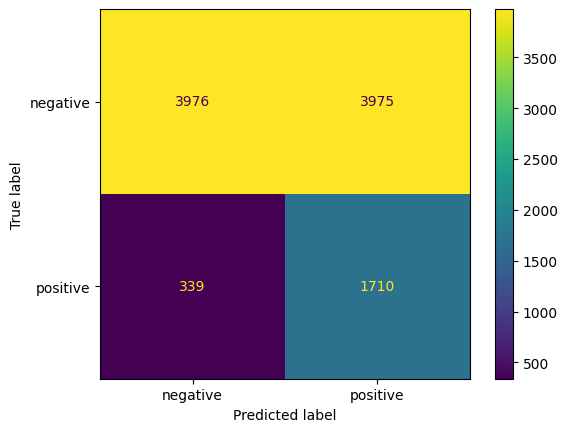

In [17]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Compute accuracy
accuracy = accuracy_score(tweets_df_sent['sentiment_human'], results_df_bin['sentiment_algo_binary'])
print("Accuracy:", accuracy)

# Step 2: Compute confusion matrix and display it
ConfusionMatrixDisplay.from_predictions(tweets_df_sent['sentiment_human'], results_df_bin['sentiment_algo_binary'])